In [1]:
import sys
sys.path.append("..")

import pandas as pd
from src.data.data_cleaning import load_config, project_path
from src.visualization.visualize import (
    plot_timeseries, plot_decomposition, plot_weekly_pattern,
    plot_monthly_pattern, plot_acf_pacf,
)

config = load_config("config/config.yaml")
df = pd.read_csv(project_path(config["data"]["interim_path"]))
df["date"] = pd.to_datetime(df["date"])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1095 non-null   datetime64[ns]
 1   sales       1095 non-null   float64       
 2   promo       1095 non-null   int64         
 3   is_holiday  1095 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 34.3 KB


,date,sales,promo,is_holiday
0,2023-01-01,380.2,0,1
1,2023-01-02,236.7,0,0
2,2023-01-03,232.4,0,0
3,2023-01-04,235.2,0,0
4,2023-01-05,345.8,1,0


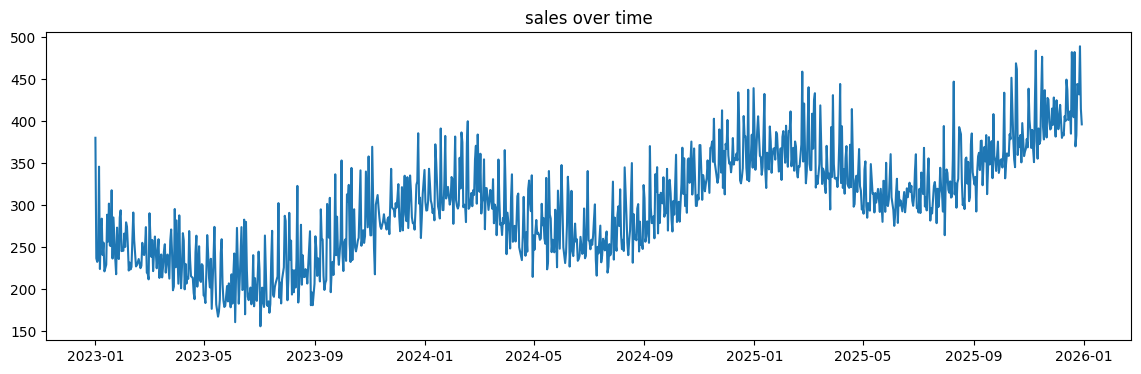

In [2]:
plot_timeseries(df, "date", "sales", config["output"]["figures_path"])

* Tren naik jelas sepanjang 3 tahun — dari sekitar 250 (awal 2023) ke sekitar 400-450 (akhir 2025)
* Terlihat pola siklus tahunan: penjualan turun di pertengahan tahun (sekitar Mei-Juli), naik lagi di akhir/awal tahun
* Volatilitas harian cukup tinggi (banyak lonjakan tajam naik-turun) — konsisten dengan efek promo yang random

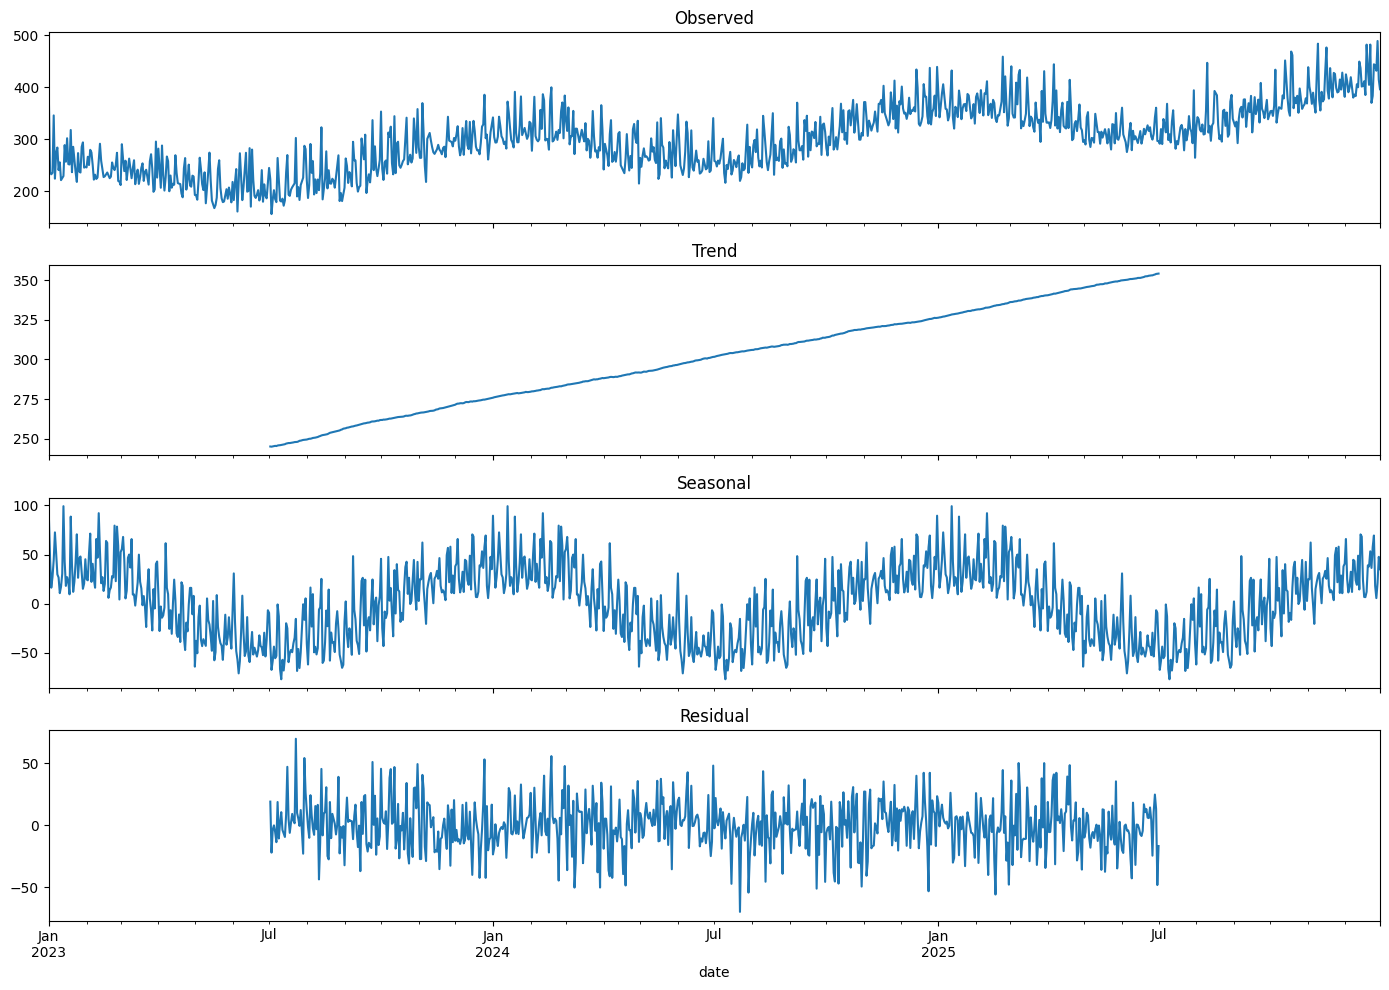

In [3]:
decomposition = plot_decomposition(df, "date", "sales", config["output"]["figures_path"], period=365)

* Trend: naik hampir linear dan konsisten, dari ~240 ke ~355 — tidak ada tanda perlambatan atau percepatan drastis
* Seasonal: pola berulang jelas dengan periode ~1 tahun, amplitudo sekitar -70 sampai +100 — mengonfirmasi ada musiman tahunan yang kuat, sesuai desain data (puncak di akhir tahun, lembah di pertengahan tahun)
* Residual: tersebar di sekitar 0 tanpa pola musiman/tren yang jelas tersisa — mengindikasikan dekomposisi berhasil menangkap sebagian besar struktur sistematis, sisanya adalah noise + kemungkinan efek promo yang belum terpisahkan

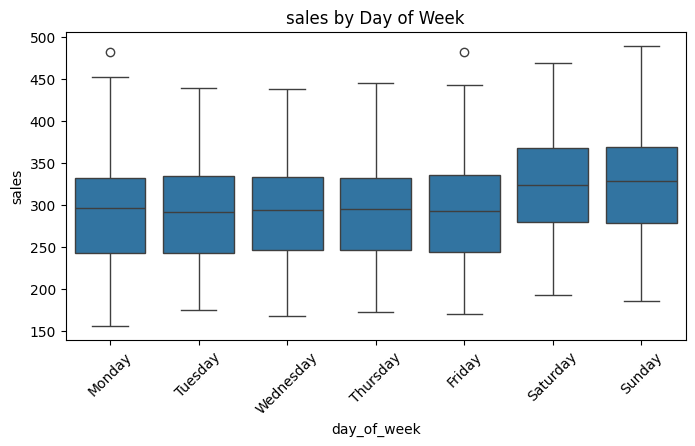

In [4]:
plot_weekly_pattern(df, "date", "sales", config["output"]["figures_path"])

* Sabtu dan Minggu jelas lebih tinggi dari Senin-Jumat — median 325-330 vs 290-295 di hari kerja
* Senin dan Jumat masing-masing punya 1 outlier tinggi (~480-485) — kemungkinan bertepatan dengan promo atau hari libur besar
* Weekday (Senin-Jumat) punya distribusi yang sangat mirip satu sama lain — tidak ada perbedaan besar antar hari kerja, mengonfirmasi pembagian biner "weekend vs weekday" sudah cukup menangkap pola mingguan, tidak perlu one-hot 7 hari terpisah

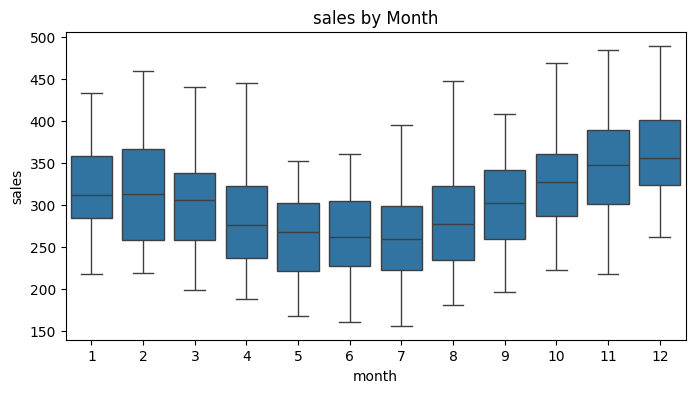

In [5]:
plot_monthly_pattern(df, "date", "sales", config["output"]["figures_path"])

* Bulan 1-2 (Jan-Feb) dan bulan 10-12 (Okt-Des) punya median tertinggi (310-355)
* Bulan 5-7 (Mei-Jul) paling rendah (~260-265) — ini adalah "lembah" musiman yang konsisten dengan seasonal component di Image 2
* Bulan 12 (Desember) juga punya rentang IQR yang melebar ke atas — kemungkinan efek holiday di akhir tahun (Natal/Tahun Baru) menambah variasi

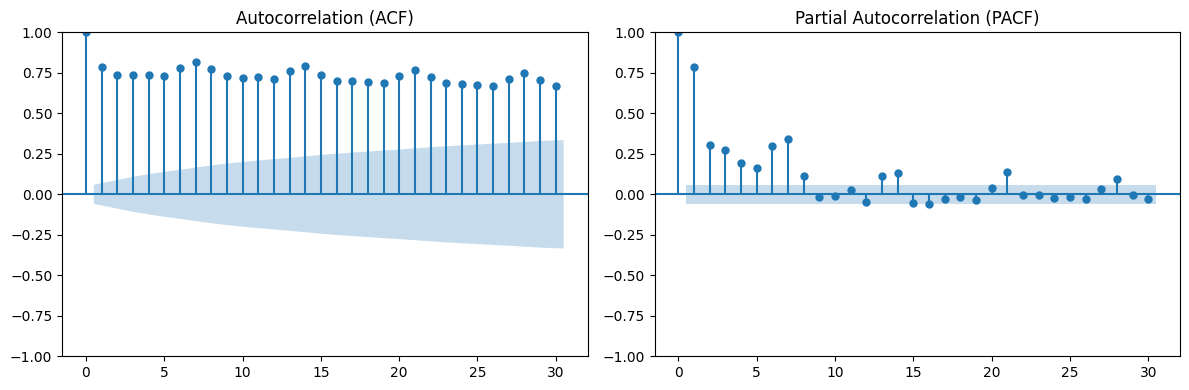

In [6]:
plot_acf_pacf(df, "sales", config["output"]["figures_path"], lags=30)

* ACF meluruh sangat lambat (masih 0.65-0.7 di lag 30) — ciri khas data yang tidak stasioner (ada tren), konsisten dengan hasil ADF test yang kemungkinan menunjukkan non-stasioner
* Lonjakan ACF di lag 7 dan kelipatannya (lag 7, 14, 21, 28 sedikit lebih tinggi dari sekitarnya) — mengonfirmasi pola mingguan yang kuat
* PACF terpotong tajam setelah lag 1-2 (nilai signifikan hanya di beberapa lag awal, lalu masuk ke area tidak signifikan) — mengindikasikan komponen AR dengan orde rendah (mendukung pilihan p=1 di parameter SARIMA)
* Ada sedikit sinyal berulang di sekitar lag 7 pada PACF juga — mendukung pemilihan seasonal_order dengan periode 7

In [7]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["sales"])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
if result[1] < 0.05:
    print("-> Data stasioner (bagus untuk model seperti ARIMA)")
else:
    print("-> Data TIDAK stasioner, perlu differencing sebelum ARIMA")

ADF Statistic: 0.2016
p-value: 0.9724
-> Data TIDAK stasioner, perlu differencing sebelum ARIMA
